In [62]:
# Import the needed libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [63]:
# Read the dataset
breast_cancer_dataset = pd.read_csv('../data/breast_cancer/wdbc.data')
# Set column names (needed since the data file doesn't have a header row)
breast_cancer_dataset.columns = [
    'ID',
    'Diagnosis',
    'radius1',
    'texture1',
    'perimeter1',
    'area1',
    'smoothness1',
    'compactness1',
    'concavity1',
    'concave_points1',
    'symmetry1',
    'fractal_dimensions1',
    'radius2',
    'texture2',
    'perimeter2',
    'area2',
    'smoothness2',
    'compactness2',
    'concavity2',
    'concave_points2',
    'symmetry2',
    'fractal_dimensions2',
    'radius3',
    'texture3',
    'perimeter3',
    'area3',
    'smoothness3',
    'compactness3',
    'concavity3',
    'concave_points3',
    'symmetry3',
    'fractal_dimensions3',
]
# Show the first 5 rows to validate that the data import has been successful
breast_cancer_dataset.head()

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
0,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [64]:
# Dropping unnecessary data. The ID is just an identifier and not needed for analysis
breast_cancer_dataset = breast_cancer_dataset.drop('ID', axis=1)
breast_cancer_dataset.head()

,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
0,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
1,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
2,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
3,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
4,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.1578,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440


In [65]:
# Show descriptive Statistics
stats = breast_cancer_dataset.describe()
stats

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
count,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,...,568.00000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000,568.000000
mean,14.120491,19.305335,91.914754,654.279754,0.096321,0.104036,0.088427,0.048746,0.181055,0.062770,...,16.25315,25.691919,107.125053,878.578873,0.132316,0.253541,0.271414,0.114341,0.289776,0.083884
std,3.523416,4.288506,24.285848,351.923751,0.014046,0.052355,0.079294,0.038617,0.027319,0.007035,...,4.82232,6.141662,33.474687,567.846267,0.022818,0.156523,0.207989,0.065484,0.061508,0.018017
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.93000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.697500,16.177500,75.135000,420.175000,0.086290,0.064815,0.029540,0.020310,0.161900,0.057697,...,13.01000,21.095000,84.102500,514.975000,0.116600,0.146900,0.114475,0.064730,0.250350,0.071412
50%,13.355000,18.855000,86.210000,548.750000,0.095865,0.092525,0.061400,0.033455,0.179200,0.061515,...,14.96500,25.425000,97.655000,685.550000,0.131300,0.211850,0.226550,0.099840,0.282050,0.080015
75%,15.780000,21.802500,103.875000,782.625000,0.105300,0.130400,0.129650,0.073730,0.195625,0.066120,...,18.76750,29.757500,125.175000,1073.500000,0.146000,0.337600,0.381400,0.161325,0.317675,0.092065
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.04000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [71]:
# Find the mode of each feature. Since this can be multiple values, the returned frame has multiple 
# rows (matching the largest amount).
breast_cancer_dataset.mode()

,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
0,B,12.34,14.93,82.61,512.2,0.1007,0.1147,0.0,0.0,0.1601,...,12.36,17.70,101.7,284.4,0.1216,0.1486,0.0,0.0,0.2226,0.07427
1,NaN,NaN,15.70,87.76,NaN,NaN,0.1206,NaN,NaN,0.1714,...,NaN,27.26,105.9,402.8,0.1223,0.3416,NaN,NaN,0.2369,NaN
2,NaN,NaN,16.84,134.70,NaN,NaN,NaN,NaN,NaN,0.1717,...,NaN,NaN,117.7,439.6,0.1234,NaN,NaN,NaN,0.2383,NaN
3,NaN,NaN,16.85,NaN,NaN,NaN,NaN,NaN,NaN,0.1769,...,NaN,NaN,NaN,458.0,0.1256,NaN,NaN,NaN,0.2972,NaN
4,NaN,NaN,17.46,NaN,NaN,NaN,NaN,NaN,NaN,0.1893,...,NaN,NaN,NaN,472.4,0.1275,NaN,NaN,NaN,0.3109,NaN
5,NaN,NaN,18.22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,489.5,0.1312,NaN,NaN,NaN,0.3196,NaN
6,NaN,NaN,18.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,546.7,0.1347,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,19.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,547.4,0.1401,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,20.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,624.1,0.1415,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,698.8,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Calculate the Inter Quartile Range from the stats returned by describe
IQR = stats.iloc[6,:]-stats.iloc[4,:]
IQR


radius1                  4.082500
texture1                 5.625000
perimeter1              28.740000
area1                  362.450000
smoothness1              0.019010
compactness1             0.065585
concavity1               0.100110
concave_points1          0.053420
symmetry1                0.033725
fractal_dimensions1      0.008422
radius2                  0.244950
texture2                 0.641100
perimeter2               1.731750
area2                   27.167500
smoothness2              0.002985
compactness2             0.019170
concavity2               0.026702
concave_points2          0.007076
symmetry2                0.008270
fractal_dimensions2      0.002281
radius3                  5.757500
texture3                 8.662500
perimeter3              41.072500
area3                  558.525000
smoothness3              0.029400
compactness3             0.190700
concavity3               0.266925
concave_points3          0.096595
symmetry3                0.067325
fractal_dimens

In [6]:
# Look at the implementation details, data types and missing data
breast_cancer_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Diagnosis            568 non-null    str    
 1   radius1              568 non-null    float64
 2   texture1             568 non-null    float64
 3   perimeter1           568 non-null    float64
 4   area1                568 non-null    float64
 5   smoothness1          568 non-null    float64
 6   compactness1         568 non-null    float64
 7   concavity1           568 non-null    float64
 8   concave_points1      568 non-null    float64
 9   symmetry1            568 non-null    float64
 10  fractal_dimensions1  568 non-null    float64
 11  radius2              568 non-null    float64
 12  texture2             568 non-null    float64
 13  perimeter2           568 non-null    float64
 14  area2                568 non-null    float64
 15  smoothness2          568 non-null    float64
 16  c

In [ ]:
# Count the number of missing values in the dataset
breast_cancer_dataset.isna().sum()

Diagnosis              0
radius1                0
texture1               0
perimeter1             0
area1                  0
smoothness1            0
compactness1           0
concavity1             0
concave_points1        0
symmetry1              0
fractal_dimensions1    0
radius2                0
texture2               0
perimeter2             0
area2                  0
smoothness2            0
compactness2           0
concavity2             0
concave_points2        0
symmetry2              0
fractal_dimensions2    0
radius3                0
texture3               0
perimeter3             0
area3                  0
smoothness3            0
compactness3           0
concavity3             0
concave_points3        0
symmetry3              0
fractal_dimensions3    0
dtype: int64

/tmp/ipykernel_59929/2150540773.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  breast_cancer_dataset.hist(ax=ax)


array([[<Axes: title={'center': 'radius1'}>,
        <Axes: title={'center': 'texture1'}>,
        <Axes: title={'center': 'perimeter1'}>,
        <Axes: title={'center': 'area1'}>,
        <Axes: title={'center': 'smoothness1'}>],
       [<Axes: title={'center': 'compactness1'}>,
        <Axes: title={'center': 'concavity1'}>,
        <Axes: title={'center': 'concave_points1'}>,
        <Axes: title={'center': 'symmetry1'}>,
        <Axes: title={'center': 'fractal_dimensions1'}>],
       [<Axes: title={'center': 'radius2'}>,
        <Axes: title={'center': 'texture2'}>,
        <Axes: title={'center': 'perimeter2'}>,
        <Axes: title={'center': 'area2'}>,
        <Axes: title={'center': 'smoothness2'}>],
       [<Axes: title={'center': 'compactness2'}>,
        <Axes: title={'center': 'concavity2'}>,
        <Axes: title={'center': 'concave_points2'}>,
        <Axes: title={'center': 'symmetry2'}>,
        <Axes: title={'center': 'fractal_dimensions2'}>],
       [<Axes: title={'c

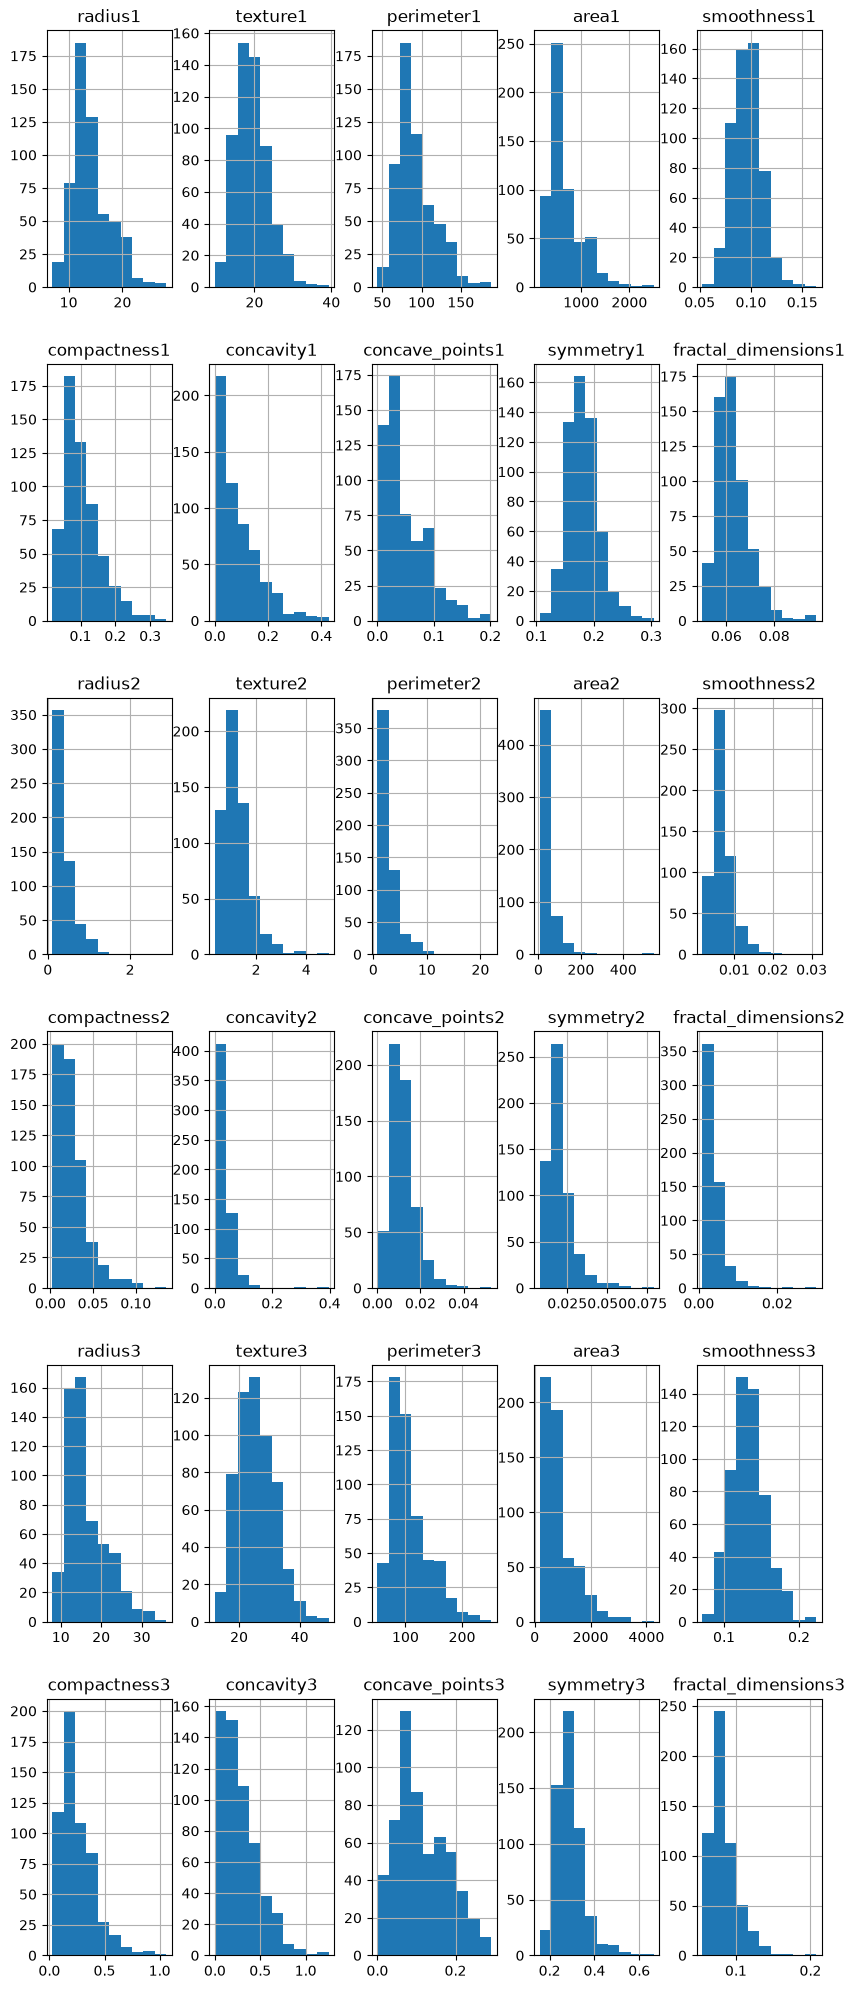

In [ ]:
# Plot the histogram for the entire dataset. We set the size of the plot to be 10 by 25 
# to ensure enough space for each individual histogram
fig, ax = plt.subplots(1, 1, figsize=(10, 25))
breast_cancer_dataset.hist(ax=ax)

array([[<Axes: title={'center': 'radius1'}>,
        <Axes: title={'center': 'smoothness1'}>]], dtype=object)

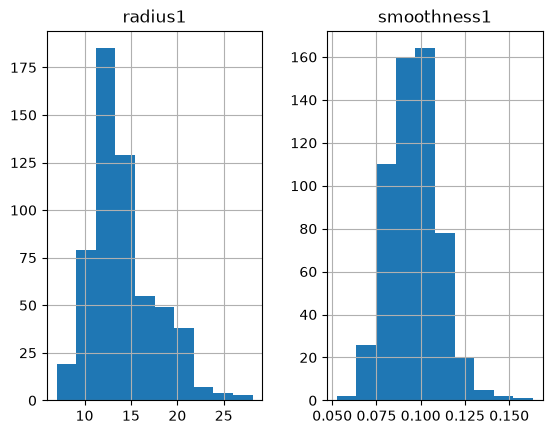

In [ ]:
# We can plot for a subset of the data to make it easier to analyse
breast_cancer_dataset[['radius1', 'smoothness1']].hist()

<Axes: ylabel='Density'>

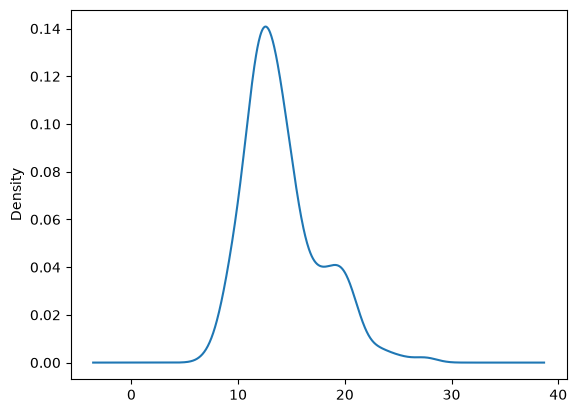

In [ ]:
# We can also use Kernel Density Estimation (KDE) plots for distribution analysis
breast_cancer_dataset['radius1'].plot.kde()

<Axes: >

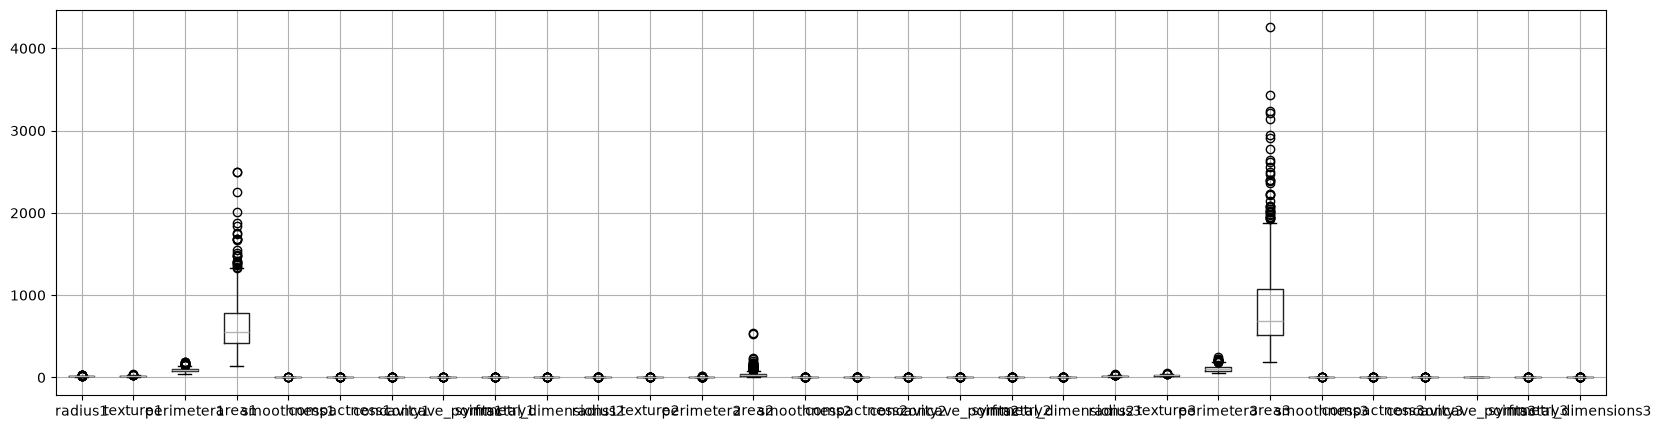

In [ ]:
# We can also use boxplots to analyse the distribution of each feature
# Problematic plot due to range and number of features
fig, ax = plt.subplots(1,1,figsize=(20, 5))
breast_cancer_dataset.boxplot()

<Axes: >

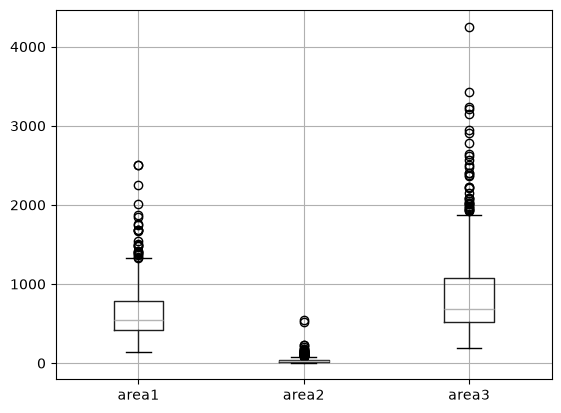

In [ ]:
# It makes sense to separate features with similar ranges into a group
area_features = ['area1','area2','area3']
breast_cancer_dataset[area_features].boxplot()

<Axes: >

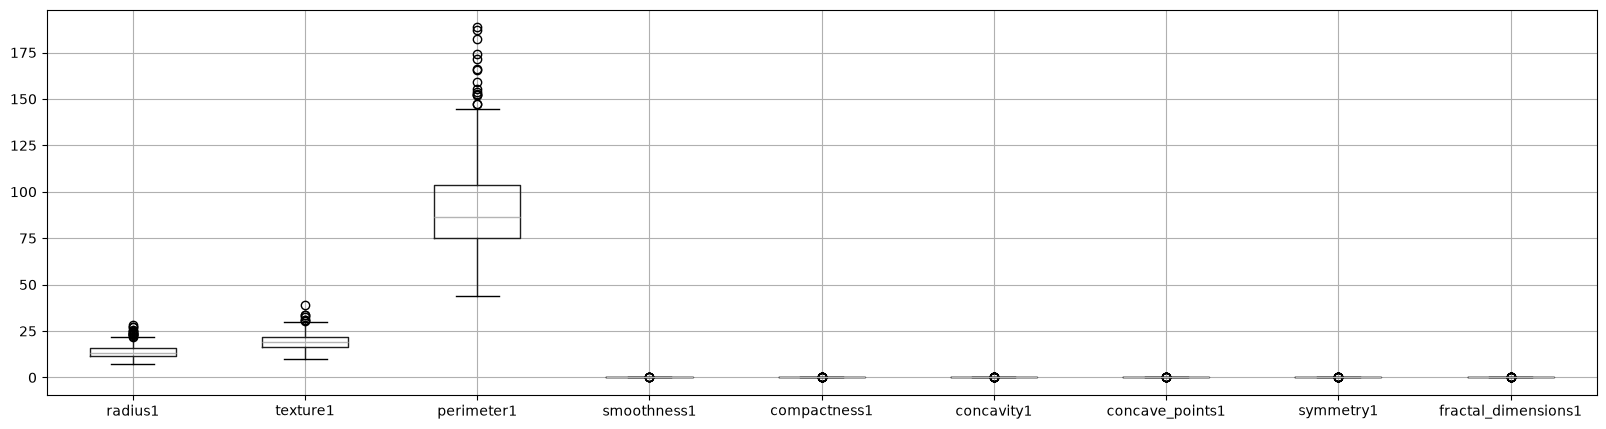

In [ ]:
# Box plot for the remaining. There are still issues with the ranges, so further separation is needed
# to ensure visible boxes.
features1 = [
    'radius1',
    'texture1',
    'perimeter1',
    'smoothness1',
    'compactness1',
    'concavity1',
    'concave_points1',
    'symmetry1',
    'fractal_dimensions1',
]
fig, ax = plt.subplots(1,1,figsize=(20, 5))
breast_cancer_dataset[features1].boxplot()

<Axes: >

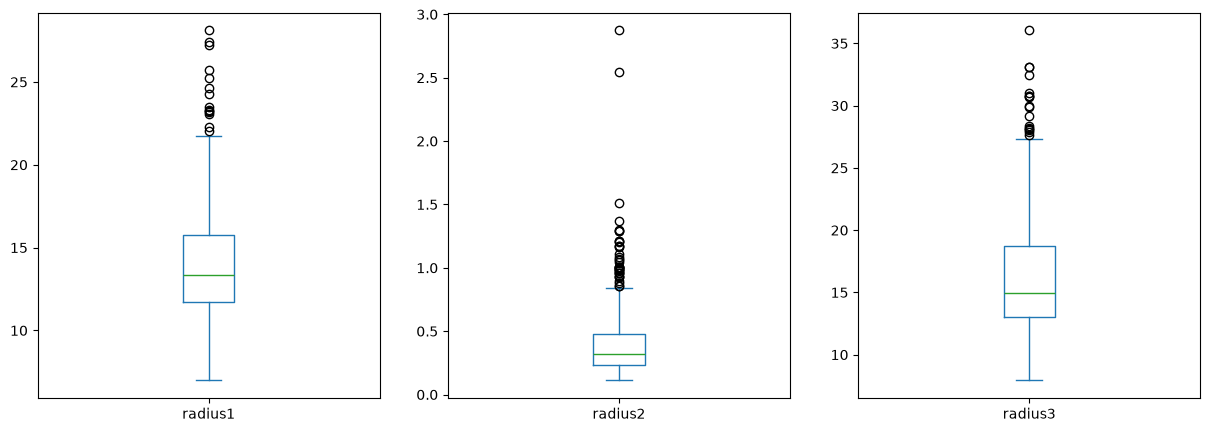

In [ ]:
# You can also plot the boxes (or any other plot) separately.
# axs contains a list of 3 individual plots/graphs which can be sent to 
# each plot function.
fig, axs = plt.subplots(1,3, figsize=(15,5))
breast_cancer_dataset['radius1'].plot.box(ax=axs[0])
breast_cancer_dataset['radius2'].plot.box(ax=axs[1])
breast_cancer_dataset['radius3'].plot.box(ax=axs[2])

In [72]:
# Do a correlation analysis of the features in the dataset (all numerical)
# Acccess the features by dropping the target from the dataset (this creates a new dataframe
# with the Diagnosis column removed)
# The correlation matrix can be hard to analyse when there are many features
correlation = breast_cancer_dataset.drop('Diagnosis', axis=1).corr()
correlation

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
radius1,1.000000,0.329383,0.997876,0.987344,0.168094,0.505129,0.676557,0.823165,0.144236,-0.317749,...,0.969964,0.300440,0.966231,0.941537,0.117392,0.411329,0.525454,0.744025,0.159877,0.003339
texture1,0.329383,1.000000,0.335918,0.326193,-0.017769,0.252038,0.315248,0.305590,0.080146,-0.068771,...,0.361964,0.912020,0.369573,0.353434,0.082714,0.290229,0.311122,0.306278,0.116263,0.127177
perimeter1,0.997876,0.335918,1.000000,0.986548,0.204505,0.555676,0.715662,0.851338,0.179100,-0.268103,...,0.969675,0.307013,0.971157,0.941735,0.148059,0.453304,0.562165,0.770783,0.184458,0.046909
area1,0.987344,0.326193,0.986548,1.000000,0.174838,0.497981,0.686232,0.824246,0.148219,-0.288560,...,0.963319,0.290565,0.960440,0.959952,0.121543,0.388554,0.511392,0.722009,0.139856,0.000382
smoothness1,0.168094,-0.017769,0.204505,0.174838,1.000000,0.657741,0.519002,0.551009,0.555259,0.582435,...,0.209018,0.039977,0.234093,0.202344,0.804667,0.469090,0.431727,0.500119,0.390161,0.496684
compactness1,0.505129,0.252038,0.555676,0.497981,0.657741,1.000000,0.881619,0.829050,0.598095,0.560161,...,0.531125,0.258877,0.585188,0.504612,0.564204,0.864097,0.815021,0.813810,0.502439,0.684961
concavity1,0.676557,0.315248,0.715662,0.686232,0.519002,0.881619,1.000000,0.920462,0.495525,0.329768,...,0.685826,0.308645,0.726703,0.673187,0.446155,0.751937,0.883184,0.859918,0.401782,0.510736
concave_points1,0.823165,0.305590,0.851338,0.824246,0.551009,0.829050,0.920462,1.000000,0.457171,0.158464,...,0.829188,0.301004,0.854468,0.808120,0.450145,0.663532,0.750169,0.909272,0.368009,0.363277
symmetry1,0.144236,0.080146,0.179100,0.148219,0.555259,0.598095,0.495525,0.457171,1.000000,0.475301,...,0.179703,0.096533,0.212084,0.170721,0.424045,0.467830,0.429023,0.425146,0.696745,0.434165
fractal_dimensions1,-0.317749,-0.068771,-0.268103,-0.288560,0.582435,0.560161,0.329768,0.158464,0.475301,1.000000,...,-0.263188,-0.046153,-0.216279,-0.241737,0.502760,0.453168,0.340717,0.167737,0.326735,0.765562


In [ ]:
# Making it colored makes the analysis a bit easier (this method only works for notebooks 
# and requires jinja2)
correlation.style.background_gradient(cmap='coolwarm')

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimensions2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
radius1,1.000000,0.329383,0.997876,0.987344,0.168094,0.505129,0.676557,0.823165,0.144236,-0.317749,0.678711,-0.096355,0.674190,0.735854,-0.222432,0.203984,0.193099,0.375435,-0.106777,-0.044473,0.969964,0.300440,0.966231,0.941537,0.117392,0.411329,0.525454,0.744025,0.159877,0.003339
texture1,0.329383,1.000000,0.335918,0.326193,-0.017769,0.252038,0.315248,0.305590,0.080146,-0.068771,0.287615,0.385865,0.295219,0.271431,0.005855,0.197833,0.146559,0.166960,0.013387,0.058030,0.361964,0.912020,0.369573,0.353434,0.082714,0.290229,0.311122,0.306278,0.116263,0.127177
perimeter1,0.997876,0.335918,1.000000,0.986548,0.204505,0.555676,0.715662,0.851338,0.179100,-0.268103,0.690955,-0.085643,0.692689,0.744540,-0.202511,0.248532,0.226890,0.406473,-0.084416,-0.007568,0.969675,0.307013,0.971157,0.941735,0.148059,0.453304,0.562165,0.770783,0.184458,0.046909
area1,0.987344,0.326193,0.986548,1.000000,0.174838,0.497981,0.686232,0.824246,0.148219,-0.288560,0.732879,-0.065375,0.727493,0.800829,-0.166555,0.210802,0.206677,0.371635,-0.074638,-0.021493,0.963319,0.290565,0.960440,0.959952,0.121543,0.388554,0.511392,0.722009,0.139856,0.000382
smoothness1,0.168094,-0.017769,0.204505,0.174838,1.000000,0.657741,0.519002,0.551009,0.555259,0.582435,0.296856,0.070139,0.290958,0.241523,0.333703,0.316475,0.247046,0.379820,0.198262,0.281917,0.209018,0.039977,0.234093,0.202344,0.804667,0.469090,0.431727,0.500119,0.390161,0.496684
compactness1,0.505129,0.252038,0.555676,0.497981,0.657741,1.000000,0.881619,0.829050,0.598095,0.560161,0.490415,0.049963,0.541495,0.447968,0.137857,0.739278,0.572048,0.644837,0.225748,0.507276,0.531125,0.258877,0.585188,0.504612,0.564204,0.864097,0.815021,0.813810,0.502439,0.684961
concavity1,0.676557,0.315248,0.715662,0.686232,0.519002,0.881619,1.000000,0.920462,0.495525,0.329768,0.627609,0.079374,0.655856,0.612945,0.100190,0.669304,0.692510,0.684690,0.173926,0.448172,0.685826,0.308645,0.726703,0.673187,0.446155,0.751937,0.883184,0.859918,0.401782,0.510736
concave_points1,0.823165,0.305590,0.851338,0.824246,0.551009,0.829050,0.920462,1.000000,0.457171,0.158464,0.694661,0.024143,0.707006,0.686826,0.028772,0.488058,0.438624,0.616413,0.090848,0.255168,0.829188,0.301004,0.854468,0.808120,0.450145,0.663532,0.750169,0.909272,0.368009,0.363277
symmetry1,0.144236,0.080146,0.179100,0.148219,0.555259,0.598095,0.495525,0.457171,1.000000,0.475301,0.296561,0.130864,0.306324,0.216374,0.188984,0.418973,0.341438,0.392571,0.447109,0.329914,0.179703,0.096533,0.212084,0.170721,0.424045,0.467830,0.429023,0.425146,0.696745,0.434165
fractal_dimensions1,-0.317749,-0.068771,-0.268103,-0.288560,0.582435,0.560161,0.329768,0.158464,0.475301,1.000000,-0.009875,0.167216,0.028913,-0.101053,0.404647,0.557960,0.445962,0.340231,0.342378,0.688115,-0.263188,-0.046153,-0.216279,-0.241737,0.502760,0.453168,0.340717,0.167737,0.326735,0.765562


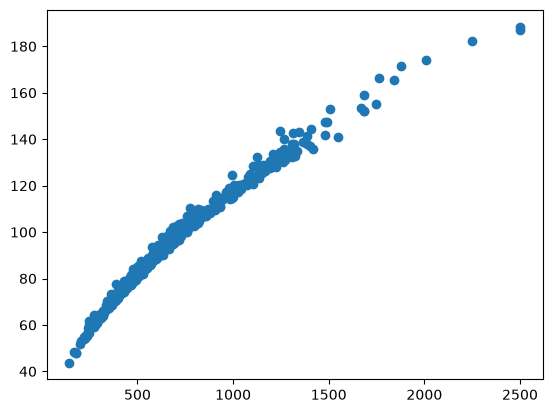

In [ ]:
# Scatter to investigate further two highly correlated features
plt.scatter(breast_cancer_dataset['area1'], breast_cancer_dataset['perimeter1'])

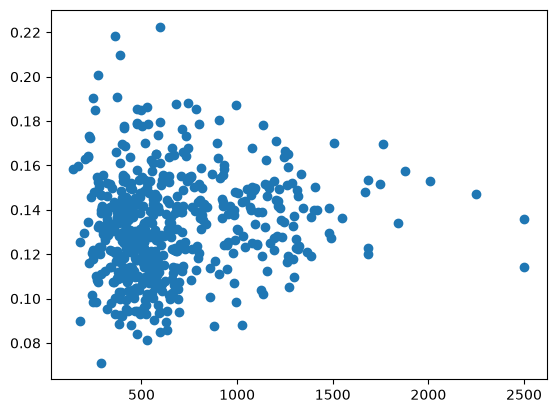

In [ ]:
# Scatter to investigate further two features with no correlation
plt.scatter(breast_cancer_dataset['area1'], breast_cancer_dataset['smoothness3'])

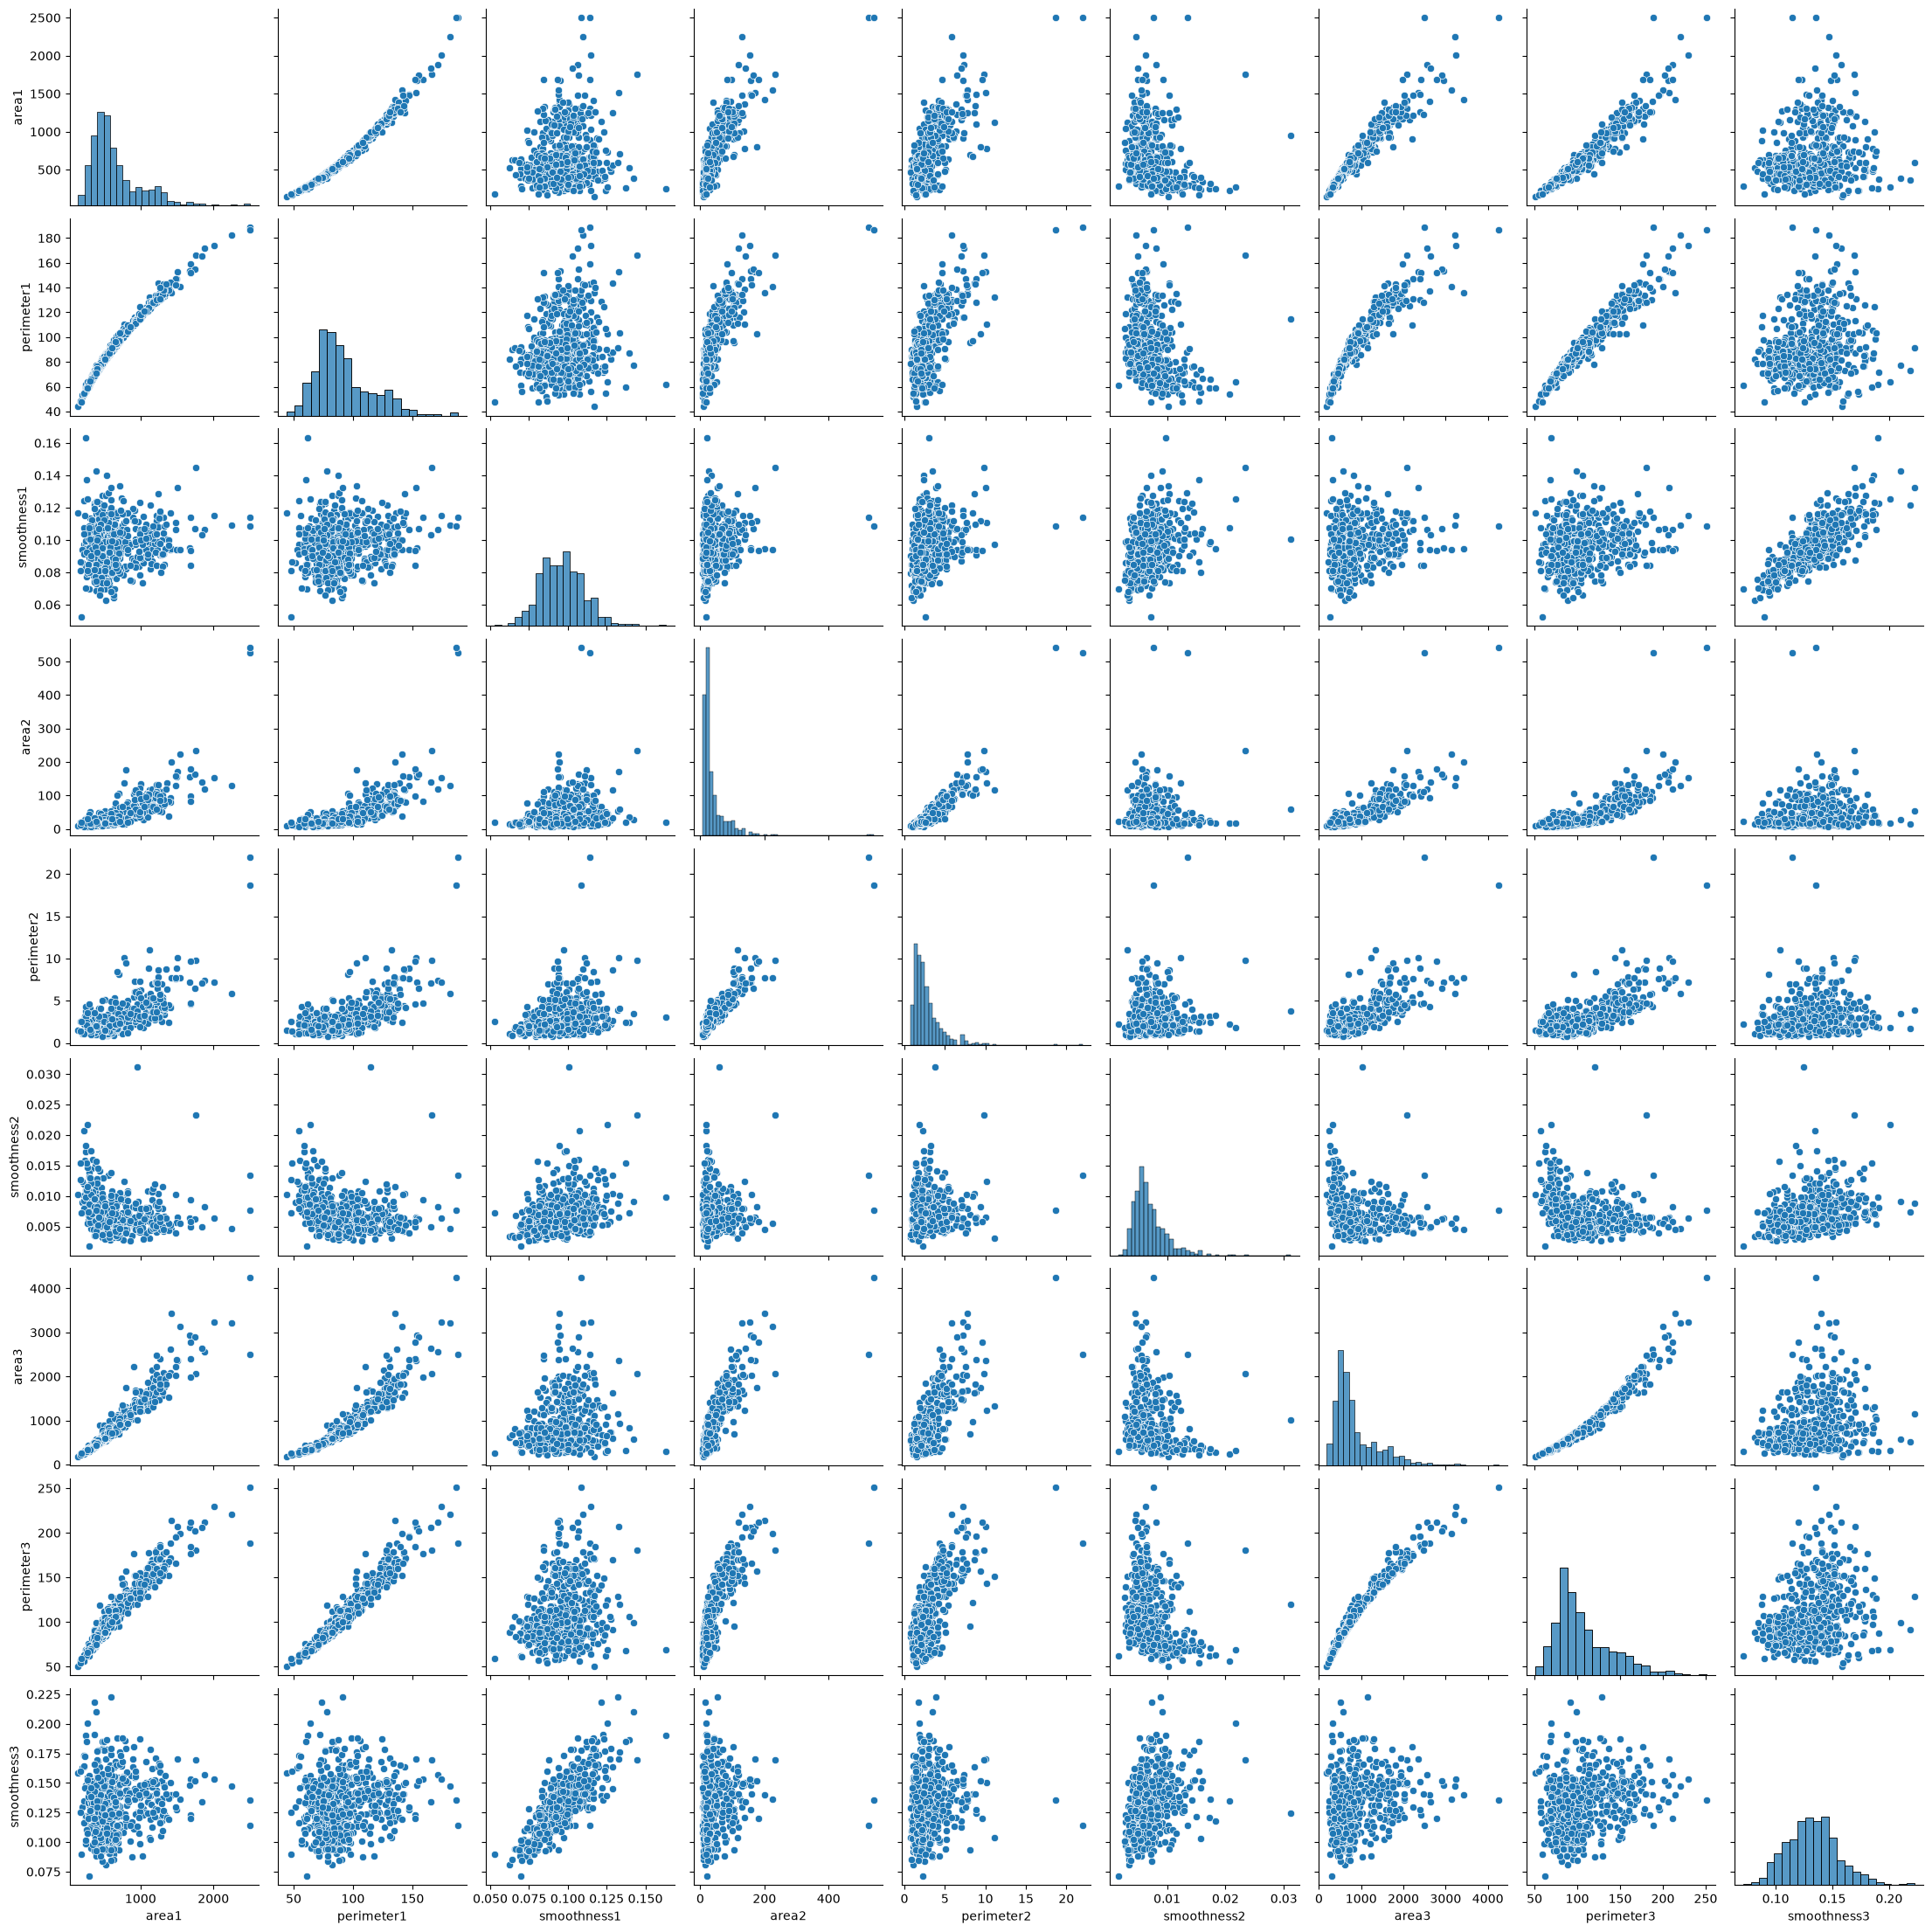

In [76]:
# A pairplot can be used to combine both univariate and multivariate analysis
# We plot only a subset to ensure readability; could be guided by correlation 
# or any other grouping criteria
sb.pairplot(data=breast_cancer_dataset[['area1', 'perimeter1', 'smoothness1', 'area2', 'perimeter2', 'smoothness2', 'area3', 'perimeter3', 'smoothness3',]])

In [30]:
# Processing

# Converting the target type to categorical

breast_cancer_dataset['Diagnosis'] = breast_cancer_dataset['Diagnosis'].astype('category')

# Splitting

# Random sampling (NOT the right way)
train_data = breast_cancer_dataset.sample(frac=0.6)
test_validation_data = breast_cancer_dataset.drop(train_data.index, axis=0)
validation_data = test_validation_data.sample(frac=0.5)
test_data = test_validation_data.drop(validation_data.index, axis=0)

print(train_data['Diagnosis'].value_counts()/train_data['Diagnosis'].count())
print(validation_data['Diagnosis'].value_counts()/validation_data['Diagnosis'].count())
print(test_data['Diagnosis'].value_counts()/test_data['Diagnosis'].count())

Diagnosis
B    0.651026
M    0.348974
Name: count, dtype: float64
Diagnosis
B    0.587719
M    0.412281
Name: count, dtype: float64
Diagnosis
B    0.60177
M    0.39823
Name: count, dtype: float64


In [ ]:
# Stratified (Correct way for classification datasets)
train_data = breast_cancer_dataset.groupby('Diagnosis').sample(frac=0.6)
test_validation_data = breast_cancer_dataset.drop(train_data.index, axis=0)
validation_data = test_validation_data.groupby('Diagnosis').sample(frac=0.5)
test_data = test_validation_data.drop(validation_data.index, axis=0)

print(train_data['Diagnosis'].value_counts()/train_data['Diagnosis'].count())
print(validation_data['Diagnosis'].value_counts()/validation_data['Diagnosis'].count())
print(test_data['Diagnosis'].value_counts()/test_data['Diagnosis'].count())

Diagnosis
B    0.627566
M    0.372434
Name: count, dtype: float64
Diagnosis
B    0.631579
M    0.368421
Name: count, dtype: float64
Diagnosis
B    0.628319
M    0.371681
Name: count, dtype: float64


In [ ]:
# Separate the dataset into features and targets

features = breast_cancer_dataset.drop('Diagnosis', axis=1)
targets = breast_cancer_dataset['Diagnosis']

In [ ]:
# Perform mean normalization on the features
features = (features - features.mean()) / features.std()
features.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimensions1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimensions3
count,5.680000e+02,568.000000,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,568.000000,5.680000e+02,...,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,5.680000e+02,568.000000,568.000000
mean,-3.127389e-17,0.000000,2.501911e-17,-6.254778e-18,-2.501911e-17,-2.501911e-17,-1.250956e-17,1.250956e-17,0.000000,-2.189172e-17,...,-3.752867e-17,1.876433e-17,-2.501911e-17,2.501911e-17,2.501911e-17,1.250956e-17,2.501911e-17,-2.501911e-17,0.000000,0.000000
std,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000,1.000000
min,-2.026298e+00,-2.237454,-1.981597e+00,-1.451393e+00,-3.110598e+00,-1.616953e+00,-1.115180e+00,-1.262296e+00,-2.747311,-1.820874e+00,...,-1.725964e+00,-2.226095e+00,-1.694267e+00,-1.221068e+00,-2.679715e+00,-1.445479e+00,-1.304948e+00,-1.746080e+00,-2.166804,-1.600914
25%,-6.876824e-01,-0.729353,-6.909272e-01,-6.652144e-01,-7.141872e-01,-7.491314e-01,-7.426431e-01,-7.363640e-01,-0.701147,-7.209942e-01,...,-6.725289e-01,-7.484813e-01,-6.877601e-01,-6.403210e-01,-6.887539e-01,-6.813105e-01,-7.545575e-01,-7.575981e-01,-0.640991,-0.692208
50%,-2.172582e-01,-0.105010,-2.349003e-01,-2.998654e-01,-3.249883e-02,-2.198625e-01,-3.408484e-01,-3.959714e-01,-0.067898,-1.783397e-01,...,-2.671224e-01,-4.346039e-02,-2.829019e-01,-3.399316e-01,-4.452924e-02,-2.663559e-01,-2.157058e-01,-2.214386e-01,-0.125613,-0.214753
75%,4.709943e-01,0.582293,4.924780e-01,3.646962e-01,6.392223e-01,5.035609e-01,5.198701e-01,6.469586e-01,0.533323,4.762574e-01,...,5.213985e-01,6.619676e-01,5.392118e-01,3.432639e-01,5.996954e-01,5.370396e-01,5.288062e-01,7.174895e-01,0.453578,0.454046
max,3.970439e+00,4.657721,3.977018e+00,5.247501e+00,4.775629e+00,4.610123e+00,4.267306e+00,3.947822e+00,4.500282,4.928370e+00,...,4.103181e+00,3.883002e+00,4.303997e+00,5.944252e+00,3.956675e+00,5.139554e+00,4.714613e+00,2.697737e+00,6.080876,6.860915


In [ ]:
# Encode the categorical features using one-hot encoding
targets_encoded = pd.get_dummies(targets)
targets_encoded

,B,M
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
563,False,True
564,False,True
565,False,True
566,False,True
